---
title: Gaussian Multivariate Bayesian State Inference
subtitle: Using RxInfer to estimate the hidden state vector
author: Kobus Esterhuysen
date: '2024-10-11'
date-modified: last-modified
categories:
  - Aerospace Industry
  - Bayesian Inference
  - Active Inference
  - RxInfer
  - Julia
image: GaussianMvStateInference.png
format:
  html:
    toc: true
    toc-depth: 4
    toc-expand: true
    toc-title: TOC
    code-fold: false
---

In [1]:
#| hide
# BASED ON
  # Kalman filtering and smoothing-1_ANNO^V5.ipynb
  # Kalman filtering and smoothing_ANNO^V4.ipynb
  # Kalman filtering and smoothing_ANNO^V3.ipynb
  # Kalman filtering and smoothing_ANNO^V2.ipynb
  # Kalman filtering and smoothing_ANNO^V1.ipynb
  # GP regression by SSM.ipynb

# DONE
# v1 starts ------------------------------------------------
# migrated to RxInfer 3.0.0
# brought over my changes from RxInfer v2.16.2
# Use \mathbf for structures
# x_tL1 & w_tL1 with nice subscripts
# v2 starts ------------------------------------------------
# \mathcal{P} & \mathcal{Q} --> \mathbf{P} & \mathbf{Q}
# insert f() & g() functions
  # works with generating data; took out again to rather have same in both places
  # does NOT work inside @model (same as https://learnableloop.ai/posts/WeightVsHeight_BLOG.html)
    # seems to take literal symbols in the code to build FFG, so
      # x[t] ~ MvNormalMeanCovariance(f(A= A, xₜ₋₁= xₜ₋₁) does not work
# generate_data() --> sim_point_data
# for 'system identification' section: x --> v
  # the 'x' here is not associated with state but just a name for one of the signals
  # 'v' will go better with the other signal called 'w'
# s (for sum, in 'system identification' section) --> z
  # need s for state (which still need to be changed)
# v3 starts ------------------------------------------------
# change x --> s (for state)
# add tildes to hidden state
# v4 starts ------------------------------------------------
# switch roles of A & B
# change P matrix to R matrix
# clean up missing data section
# standardize symbols to DeVries
# have fp() & fr() in envir, but not in agent
  # maybe in future can remove fp() & fr() from envir too
      # so that they look more similar
      # however, I need to have fp() & fr() implemented somewhere 
# v5 starts ------------------------------------------------
# clean
# v1 starts ------------------------------------------------
# change to 3D rotation
# update narrative

# TODO
# insert (modified) CRISP-DM structure
# replace code vars with math symbols
  # makes mapping between literature and code better to enhance understanding
  # make expressions more concise due to reduced wordyness
# replace hardcoded parameters with symbols


Multivariate Bayesian State estimation is performed using the `RxInfer` Julia package. The hidden states are a vector of three Gaussians.

In [1]:
versioninfo() ##. Julia version

Julia Version 1.10.0
Commit 3120989f39b (2023-12-25 18:01 UTC)
Build Info:
  Official https://julialang.org/ release
Platform Info:
  OS: Linux (x86_64-linux-gnu)
  CPU: 12 × Intel(R) Core(TM) i7-8700B CPU @ 3.20GHz
  WORD_SIZE: 64
  LIBM: libopenlibm
  LLVM: libLLVM-15.0.7 (ORCJIT, skylake)
  Threads: 1 on 12 virtual cores
Environment:
  JULIA_NUM_THREADS = 


In [2]:
# Activate local environment, see `Project.toml`
import Pkg; Pkg.activate(".."); Pkg.instantiate();

using RxInfer, BenchmarkTools, Random, LinearAlgebra, Plots, LaTeXStrings, Distributions, StableRNGs

  Activating project at `/workspaces/3.0.0_RxInfer.jl/examples`


In [3]:
Pkg.status()

Status `/workspaces/3.0.0_RxInfer.jl/examples/Project.toml`
⌃ [b4ee3484] BayesBase v1.2.1
  [6e4b80f9] BenchmarkTools v1.5.0
  [336ed68f] CSV v0.10.14
⌃ [159f3aea] Cairo v1.0.5
  [a81c6b42] Compose v0.9.5
  [a93c6f00] DataFrames v1.6.1
⌃ [31c24e10] Distributions v0.25.108
⌃ [62312e5e] ExponentialFamily v1.4.1
⌃ [587475ba] Flux v0.14.11
  [38e38edf] GLM v1.9.0
⌅ [b3f8163a] GraphPPL v4.0.2
⌃ [a2cc645c] GraphPlot v0.5.2
  [f526b714] GraphViz v0.2.0
⌃ [86223c79] Graphs v1.9.0
⌃ [34004b35] HypergeometricFunctions v0.3.23
⌃ [7073ff75] IJulia v1.24.2
  [4138dd39] JLD v0.13.5
  [b964fa9f] LaTeXStrings v1.3.1
  [b81a8e73] LatexSVG v0.3.1
⌃ [23fbe1c1] Latexify v0.16.3
  [429524aa] Optim v1.9.4
⌃ [3bd65402] Optimisers v0.2.20
⌃ [3b7a836e] PGFPlots v3.4.4
  [8314cec4] PGFPlotsX v1.6.1
  [d96e819e] Parameters v0.12.3
⌃ [91a5bcdd] Plots v1.40.1
⌃ [92933f4c] ProgressMeter v1.10.0
⌅ [a194aa59] ReactiveMP v4.0.0
  [37e2e3b7] ReverseDiff v1.15.3
⌃ [df971d30] Rocket v1.8.0
⌃ [86711068] RxInfer v3.0.0
  [

## Multivariate Linear Gaussian State Space Model

A multivariate Multivariate Linear Gaussian State Space Model (LGSSM) can be described with the equations:

$$\begin{aligned}
 p(\mathbf{s}_t|\mathbf{s}_{t - 1}) & = \mathcal{N}(\mathbf{s}_t|\mathbf{\breve{B}} \mathbf{s}_{t - 1}, \mathbf{Q}),\\
 p(\mathbf{y}_t|\mathbf{s}_t) & = \mathcal{N}(\mathbf{y}_t|\mathbf{\breve{A}} \mathbf{s}_t, \mathbf{R}),
\end{aligned}$$

where $\mathbf{s}_t$ are hidden states, $\mathbf{y}_t$ are noisy observations, $\mathbf{\breve{B}}$, $\mathbf{\breve{A}}$ are state transition and observation matrices, $\mathbf{Q}$ and $\mathbf{R}$ are state transition noise and observation noise covariance matrices.

To make things more interesting, we will use a state space model that is subject to rotation in 3 dimensions, i.e. along the x, y, and z axes. This is a common use case for flying aircraft that rotate relative to a ground-based frame of coordinates. Once we have the transition and observation matrices for rotation around all 3 axes, we will use these matrices for the final state space model. Eventually, we will perform bayesian multivariate inference of the random vector $\mathbf{s}_t$. Note that this state space model does not capture the complete dynamics of a rotating object - only the location is included. 

1. **State Space Model without Rotation (3D)**

$$
\mathbf{s}_t = \mathbf{\breve{B}} \mathbf{s}_{t-1}
$$
$$
\mathbf{y}_t = \mathbf{\breve{A}} \mathbf{s}_t
$$

where:
$$
\mathbf{s}_t = \begin{bmatrix} s_{1t} \\ s_{2t} \\ s_{3t} \end{bmatrix} = \begin{bmatrix} x_{t} \\ y_{t} \\ z_{t} \end{bmatrix}
$$
and $x, y, z$ is the location coordinates in 3D space.

$$
\mathbf{y}_t = \begin{bmatrix} y_{1t} \\ y_{2t} \\ y_{3t} \end{bmatrix}
$$

2. **Rotation Matrices for Each Axis**

- Rotation around the x-axis by $\alpha$:

$$
\mathbf{\Phi}_x(\alpha) = \begin{bmatrix}
1 & 0 & 0 \\
0 & \cos(\alpha) & -\sin(\alpha) \\
0 & \sin(\alpha) & \cos(\alpha)
\end{bmatrix}
$$

- Rotation around the y-axis by $\beta$:

$$
\mathbf{\Phi}_y(\beta) = \begin{bmatrix}
\cos(\beta) & 0 & \sin(\beta) \\
0 & 1 & 0 \\
-\sin(\beta) & 0 & \cos(\beta)
\end{bmatrix}
$$

- Rotation around the z-axis by $\gamma$:

$$
\mathbf{\Phi}_z(\gamma) = \begin{bmatrix}
\cos(\gamma) & -\sin(\gamma) & 0 \\
\sin(\gamma) & \cos(\gamma) & 0 \\
0 & 0 & 1
\end{bmatrix}
$$

3. **Combined Rotation Matrix in 3D**

$$
\mathbf{\Phi}(\alpha, \beta, \gamma) = \mathbf{\Phi}_z(\gamma) \mathbf{\Phi}_y(\beta) \mathbf{\Phi}_x(\alpha)
$$

$$
\mathbf{\Phi}(\alpha, \beta, \gamma) = \begin{bmatrix}
\cos(\gamma)\cos(\beta) & \cos(\gamma)\sin(\beta)\sin(\alpha) - \sin(\gamma)\cos(\alpha) & \cos(\gamma)\sin(\beta)\cos(\alpha) + \sin(\gamma)\sin(\alpha) \\
\sin(\gamma)\cos(\beta) & \sin(\gamma)\sin(\beta)\sin(\alpha) + \cos(\gamma)\cos(\alpha) & \sin(\gamma)\sin(\beta)\cos(\alpha) - \cos(\gamma)\sin(\alpha) \\
-\sin(\beta) & \cos(\beta)\sin(\alpha) & \cos(\beta)\cos(\alpha)
\end{bmatrix}
$$

4. **State Space Model with Rotation (3D)**

$$
\mathbf{s}_t = \mathbf{\breve{B}} \mathbf{\Phi}(\alpha, \beta, \gamma) \mathbf{s}_{t-1} = \mathbf{\Phi}(\alpha, \beta, \gamma) \mathbf{s}_{t-1} = \mathbf{B} \mathbf{s}_{t-1}
$$
(when $\mathbf{\breve{B}}$ is set to the identity matrix)

and the output equation:

$$
\mathbf{y}_t = \mathbf{\breve{A}} \mathbf{\Phi}(\alpha, \beta, \gamma) \mathbf{s}_t = \mathbf{\Phi}(\alpha, \beta, \gamma) \mathbf{s}_t = \mathbf{A} \mathbf{s}_t
$$
(when $\mathbf{\breve{A}}$ is set to the identity matrix).

In [7]:
# _seed = 1234
_seed = 777
# _rng = MersenneTwister(1234)
_rng = MersenneTwister(_seed)

## We will model 2-dimensional observations with rotation matrix `B`
## To avoid clutter we also assume that matrices `B`, `A`, `Q`, and `R`
## are known and fixed for all time-steps
# _s̃₀ = [ 10.0, -10.0 ]
# _s̃₀ = [ 15.0, 15.0, 15.0 ]
# _s̃₀ = [ 0.0, 0.0, 0.0 ]
_s̃₀ = [ 1.0, 2.0, 3.0 ]

# _θ̃ = π / 35
# _α̃ = π / 35
# _α̃ = π / 125
_α̃ = 0.025 ## radians
# _β̃ = π / 125
_β̃ = 0.03 ## radians
# _γ̃ = π / 125
_γ̃ = 0.02 ## radians

_Φ̃_x = [1        0        0;
        0        cos(_α̃)  -sin(_α̃);
        0        sin(_α̃)  cos(_α̃)]
_Φ̃_y = [cos(_β̃)  0        sin(_β̃);
        0        1        0;
        -sin(_β̃) 0        cos(_β̃)]
_Φ̃_z = [cos(_γ̃)  -sin(_γ̃) 0;
        sin(_γ̃)  cos(_γ̃)  0;
        0        0        1]
_Φ̃ = _Φ̃_x*_Φ̃_y*_Φ̃_z

# _B̃ = [ cos(_θ̃) -sin(_θ̃); 
#        sin(_θ̃) cos(_θ̃) ]
# _B̃ = [ cos(_γ̃)cos(_β̃)  cos(_γ̃)sin(_β̃)sin(_α̃)-sin(_γ̃)cos(α̃)  cos(_γ̃)sin(_β̃)cos(_α̃)+sin(_γ̃)sin(_α̃);
#        sin(_γ̃)cos(_β̃)  sin(_γ̃)sin(_β̃)sin(_α̃)+cos(_γ̃)cos(α̃)  sin(_γ̃)sin(_β̃)cos(_α̃)-cos(_γ̃)sin(_α̃);
#        sin(_β̃)         cos(_β̃)sin(_α̃)                       cos(_β̃)cos(_α̃) ]
_B̃ = [1 0 0;
      0 1 0;
      0 0 1]*_Φ̃


# _Ã = diageye(2)
_Ã = [1 0 0;
      0 1 0;
      0 0 1]*_Φ̃
# _Ã = diageye(3)

# _Q̃ = diageye(2)
_Q̃ = diageye(3)

# _R̃ = 25.0 .* diageye(2)
# _R̃ = 25.0 .* diageye(3)
_R̃ = 20.0 .* diageye(3)

# _T = 300; ## number of observations
_T = 200; ## number of observations

In [24]:
_Φ̃

3×3 Matrix{Float64}:
  0.99935    -0.0199897   0.0299955
  0.0207421   0.999473   -0.0249861
 -0.0294802   0.0255921   0.999238

In [25]:
_B̃

3×3 Matrix{Float64}:
  0.99935    -0.0199897   0.0299955
  0.0207421   0.999473   -0.0249861
 -0.0294802   0.0255921   0.999238

In [26]:
_Ã

3×3 Matrix{Float64}:
  0.99935    -0.0199897   0.0299955
  0.0207421   0.999473   -0.0249861
 -0.0294802   0.0255921   0.999238

In [27]:
_Q̃

3×3 Matrix{Float64}:
 1.0  0.0  0.0
 0.0  1.0  0.0
 0.0  0.0  1.0

In [28]:
_R̃

3×3 Matrix{Float64}:
 20.0   0.0   0.0
  0.0  20.0   0.0
  0.0   0.0  20.0

## The Generative Process

Next, we will generate some synthetic data.

### Provision function ($f_p$)
The *provision* function, provides another *covariate vector*. Because this is a *sequential* system, the provision function defines the transition between the previous state and the current state. This special case of the provision function is known as a *transition* function and it returns a *provision/pre-state*:

$$\tilde{\mathbf{p}}_{t} = f_p(\tilde{\mathbf{s}}_{t-1}) = f_B(\tilde{\mathbf{s}}_{t-1}) = \tilde{\mathbf{B}} \tilde{\mathbf{s}}_{t-1}$$

When we add *system noise* the next *state* is produced:

$$\tilde{\mathbf{s}}_{t} = \mathcal{N}(\tilde{\mathbf{p}}_{t}, \mathbf{\tilde{Q}})$$

The `tilde`s indicate that the parameters and variables are hidden and not observed.

In [10]:
## provision function, provides another covariate vector
function fₚ(; B̃, s̃ₜ₋₁)
    return B̃*s̃ₜ₋₁
end
fₚ(B̃=_B̃, s̃ₜ₋₁=_s̃₀)

3-element Vector{Float64}:
 1.049357295076791
 1.9447288135798293
 3.019417014740016

### Response function ($f_r$)
The *response* function, provides the response to the covariate vector, called the *response*:
$$\tilde{\mathbf{r}}_{t} = f_r(\tilde{\mathbf{s}}_{t}) = f_A(\tilde{\mathbf{s}}_{t}) = \tilde{\mathbf{A}} \tilde{\mathbf{s}}_{t} $$

After combining with *observation noise* the *observation* is produced:

$$\mathbf{y}_{t} = \mathcal{N}(\tilde{\mathbf{r}}_{t}, \mathbf{\tilde{R}})$$


The `tilde`s indicate that the parameters and variables are hidden and not observed.

In [11]:
## response function, provides the response to covariate vector
function fᵣ(; Ã, s̃ₜ)
    return Ã*s̃ₜ
end
fᵣ(; Ã=_Ã, s̃ₜ=_s̃₀)

3-element Vector{Float64}:
 1.049357295076791
 1.9447288135798293
 3.019417014740016

In [12]:
## Data comes from either a simulation/lab (sim|lab) OR from the field (fld)
## Data are handled either in batches (batch) OR online as individual points (point)
## Batch data accumulates either
    ## along the depth/examples dimension/axis (into the screen/page), OR
        ## typical for supervised & unsupervised learning
    ## along the time dimension/axis (down the screen page)
        ## typical for sequential decision learning (reinforcement learning & active inference)
function sim_batch_data(rng, T, B̃, Ã, Q̃, R̃) ## simulated batch data
    s̃ₜ₋₁ = _s̃₀
    p̃ = Vector{Vector{Float64}}(undef, T)
    s̃ = Vector{Vector{Float64}}(undef, T)
    r̃ = Vector{Vector{Float64}}(undef, T)
    y = Vector{Vector{Float64}}(undef, T)
    for t in 1:T
        ## p̃[t] = B̃*s̃ₜ₋₁
        p̃[t] = fₚ(B̃=B̃, s̃ₜ₋₁=s̃ₜ₋₁)
        s̃[t] = rand(rng, MvNormal(p̃[t], Q̃))

        ## r̃[t] = Ã*s̃[t]
        r̃[t] = fᵣ(Ã=Ã, s̃ₜ=s̃[t])
        y[t] = rand(rng, MvNormal(r̃[t], R̃))

        s̃ₜ₋₁ = s̃[t]
    end
    return s̃, y
end

sim_batch_data (generic function with 1 method)

In [13]:
_s̃, _y = sim_batch_data(_rng, _T, _B̃, _Ã, _Q̃, _R̃);

In [14]:
_s̃

200-element Vector{Vector{Float64}}:
 [0.816809072166705, 1.7217016515618577, 1.7266544980425234]
 [0.8462870749788376, 1.7866860719285167, 2.284274407952872]
 [0.9240522716813285, 1.418720769965815, 0.8247663268344083]
 [1.5074917335918394, 0.7066355754400989, 0.8491162345690277]
 [0.004147904602415986, 0.08005081422059745, 1.3484301531004605]
 [-0.40918536446570625, 0.5108956198778928, 1.2731758674141656]
 [-0.29479303139789226, 0.15609530935162597, 2.960739501191896]
 [-0.8665382984624709, 0.16374219670328205, 3.088073982225083]
 [-0.23988074147935623, 1.1424146037019616, 2.1747840274034957]
 [-1.0003584001330097, 2.852304474516476, 1.415656287370715]
 ⋮
 [-2.537308148940686, 15.591255092640719, 31.074458843049115]
 [-2.1058359114778606, 13.06175160006155, 32.669454354693556]
 [-0.0028260097871883882, 11.648552923438668, 33.356051855748966]
 [0.5719478763216154, 10.351997913061277, 34.50540423895058]
 [0.8630023982128899, 9.221911298703859, 35.250394798844084]
 [1.529652990431234, 1

In [15]:
_y

200-element Vector{Vector{Float64}}:
 [-3.169472568477776, -3.0112527573196353, -7.009918788993621]
 [-0.19736298654548257, -0.9315849230039661, 4.794843936719561]
 [-4.288405615039999, -5.762609514878842, -8.122024186064301]
 [2.8069893736881704, 1.7982263833951335, 7.44462480949098]
 [4.438067867580971, 0.19944421500499462, 9.017867444981764]
 [6.993569706363068, -3.1249164236964346, 0.9734242907700942]
 [-3.1965703217997126, 3.819146546268818, 2.698419965079931]
 [-1.1740176313445088, 0.04818588007655261, -4.817597171181123]
 [8.627593419582793, -0.6712097565032804, 8.148547430458786]
 [-9.742187368874497, 0.8006839079242203, 3.5438536430998697]
 ⋮
 [-1.6344882281183137, 20.829889441875068, 23.274840442528472]
 [1.2481039038512645, 7.542168851587531, 30.462872006215893]
 [7.131212683295738, 15.018484882402486, 41.0097343948868]
 [4.849334373916948, 7.283164402494926, 36.43111168355113]
 [2.6856851138600195, 16.090514888838772, 39.147352264172525]
 [-4.122825845486582, 12.32499147730

Let's visualize the synthesized dataset. Lines represent the hidden states that need to be estimated/inferred. We only have acces to noisy observations which are represented as dots.

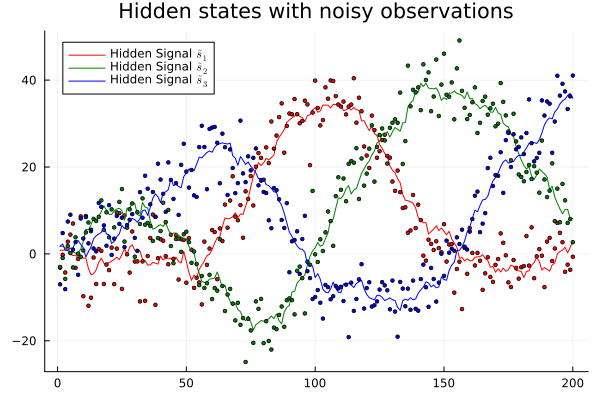

In [16]:
_p = plot(title="Hidden states with noisy observations")

_p = plot!(_p, getindex.(_s̃, 1), label="Hidden Signal " * L"\tilde{s}_1", color=:red)
_p = scatter!(_p, getindex.(_y, 1), label=false, markersize=2, color=:red)

_p = plot!(_p, getindex.(_s̃, 2), label="Hidden Signal " * L"\tilde{s}_2", color=:green)
_p = scatter!(_p, getindex.(_y, 2), label=false, markersize=2, color=:green)

_p = plot!(_p, getindex.(_s̃, 3), label="Hidden Signal " * L"\tilde{s}_3", color=:blue)
_p = scatter!(_p, getindex.(_y, 3), label=false, markersize=2, color=:blue)

plot(_p)

## The Generative Model
We now use `RxInfer`:

In [17]:
@model function rotate_ssm(y, s₀, B, A, Q, R)
    s_prior ~ MvNormalMeanCovariance(mean(s₀), cov(s₀))
    sₜ₋₁ = s_prior
    for t in 1:length(y)
        s[t] ~ MvNormalMeanCovariance(B*sₜ₋₁, Q) ## `s` is a sequence of hidden states
        ##- s[t] ~ MvNormalMeanCovariance(f(B= B, sₜ₋₁= sₜ₋₁), Q) ## `s` is a sequence of hidden states
        y[t] ~ MvNormalMeanCovariance(A*s[t], R) ## `y` is a sequence of "clamped" observations
        sₜ₋₁ = s[t]
    end
end

Specify a prior for the initial hidden state:

In [18]:
# _s̃₀ = MvNormalMeanCovariance(zeros(2), 100.0*diageye(2));
# _s̃₀ = MvNormalMeanCovariance(zeros(3), 100.0*diageye(3));
_s̃₀ = MvNormalMeanCovariance(zeros(3), 10.0*diageye(3));

Perform inference:

In [19]:
## We assume the _B̃, _Ã, _Q̃, _R̃ are known, i.e. not hidden, even though the tildes
## in their names indicate that they are hidden 
_result = infer(
    model=       rotate_ssm(s₀=_s̃₀, B=_B̃, A=_Ã, Q=_Q̃, R=_R̃),
    data=        (y = _y,),
    free_energy= true
);

Extract the results:

In [20]:
_result.posteriors

Dict{Symbol, Any} with 2 entries:
  :s       => MvNormalWeightedMeanPrecision{Float64, Vector{Float64}, Matrix{Fl…
  :s_prior => MvNormalWeightedMeanPrecision(…

In [21]:
_smarginals  = _result.posteriors[:s]

Visualize:

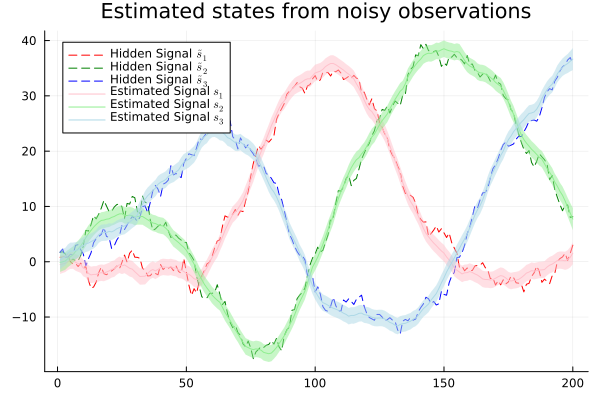

In [22]:
_p = plot(title="Estimated states from noisy observations")
_p = plot!(_p, getindex.(_s̃, 1), label="Hidden Signal " * L"\tilde{s}_1", color=:red, linestyle=:dash)
_p = plot!(_p, getindex.(_s̃, 2), label="Hidden Signal " * L"\tilde{s}_2", color=:green, linestyle=:dash)
_p = plot!(_p, getindex.(_s̃, 3), label="Hidden Signal " * L"\tilde{s}_3", color=:blue, linestyle=:dash)

_p = plot!(_p, getindex.(mean.(_smarginals), 1), ribbon=getindex.(var.(_smarginals), 1) .|> sqrt, fillalpha=0.5, label="Estimated Signal " * L"s_1", color=:pink)
_p = plot!(_p, getindex.(mean.(_smarginals), 2), ribbon=getindex.(var.(_smarginals), 2) .|> sqrt, fillalpha=0.5, label="Estimated Signal " * L"s_2", color=:lightgreen)
_p = plot!(_p, getindex.(mean.(_smarginals), 3), ribbon=getindex.(var.(_smarginals), 3) .|> sqrt, fillalpha=0.5, label="Estimated Signal " * L"s_3", color=:lightblue)
plot(_p)

As we can see from our plot, estimated signal resembles closely to the real hidden states with small variance. We maybe also interested in the value for minus log evidence:

In [23]:
## given the analytical solution, the free energy will be equal to the negative log evidence
_logevidence = -_result.free_energy; 
_logevidence

1-element Vector{Float64}:
 -1814.8622915900946